# Generative Modelling Case Study
**Module:** 7PAM2015-0105 Advanced Research Topics
**Seed:** `torch.manual_seed()`

**Report angle:** Minibatch Discrimination as a general-purpose anti-mode-collapse regulariser — does it help on a 2D Swiss roll manifold, does it carry over to an image DCGAN, and does the failure mode reappear on heavy-tailed tabular data?

**Differentiators vs cohort:**
- Part 1.2 distribution: **flattened 2D Swiss roll** (genuine manifold, not a mixture)
- Part 1.3 architecture modification: **Minibatch Discrimination in D** (Salimans et al., 2016)

**Hardware target:** Colab T4 GPU (CPU fall-back supported).


## 0. Setup

In [ ]:
# Colab-safe installs. Skip silently on local envs.
try:
    import google.colab  # noqa
    IN_COLAB = True
    !pip install -q medmnist pytorch-fid
except ImportError:
    IN_COLAB = False
print('Colab:', IN_COLAB)

In [1]:
import os, math, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp

SEED = 12
torch.manual_seed(SEED); np.random.seed(SEED)
DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEV)

Device: cpu


## Part 1.1 — Reproduce the tutorial sine-wave GAN
Standard MLP generator / discriminator, z ∈ ℝ¹⁶, two 128-unit hidden layers, Adam (lr=2e-4, β=(0.5,0.999)), 2000 iterations.
We record the final losses and overlay real/generated points.

Final D=1.306  G=0.884


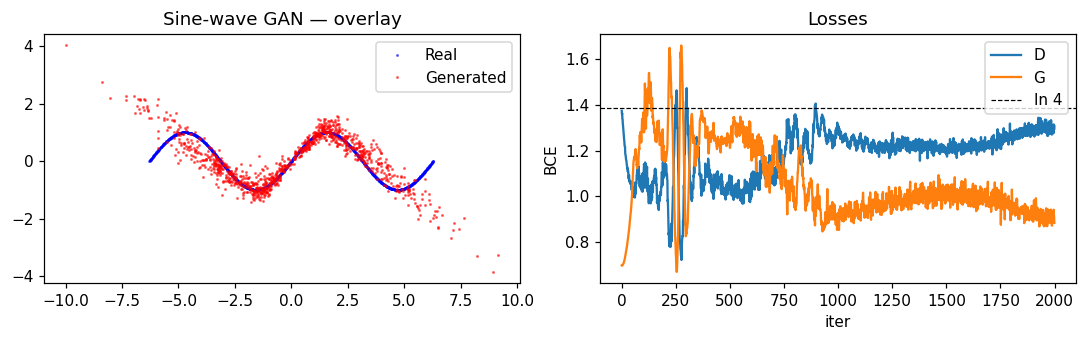

In [2]:
# 1024 evenly-spaced samples from y = sin(x), x ∈ [-2π, 2π]
N = 1024
x = np.linspace(-2*np.pi, 2*np.pi, N).astype('float32')
y = np.sin(x).astype('float32')
real = np.stack([x, y], axis=1); real_t = torch.tensor(real, device=DEV)

class G_sine(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2))
    def forward(self, z): return self.net(z)

class D_sine(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

g = G_sine().to(DEV); d = D_sine().to(DEV)
og = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5, 0.999))
od = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()
d_hist, g_hist = [], []
BS, ITERS = 256, 2000
for it in range(ITERS):
    idx = torch.randint(0, N, (BS,), device=DEV)
    xr = real_t[idx]
    z = torch.randn(BS, 16, device=DEV); xf = g(z).detach()
    od.zero_grad()
    ld = bce(d(xr), torch.full((BS,1), 0.9, device=DEV)) + bce(d(xf), torch.zeros(BS,1, device=DEV))
    ld.backward(); od.step()
    z = torch.randn(BS, 16, device=DEV)
    og.zero_grad()
    lg = bce(d(g(z)), torch.ones(BS,1, device=DEV))
    lg.backward(); og.step()
    d_hist.append(ld.item()); g_hist.append(lg.item())

with torch.no_grad():
    fake = g(torch.randn(N, 16, device=DEV)).cpu().numpy()
print(f'Final D={d_hist[-1]:.3f}  G={g_hist[-1]:.3f}')
fig, ax = plt.subplots(1, 2, figsize=(10,3.2), dpi=110)
ax[0].plot(real[:,0], real[:,1], 'b.', ms=2, alpha=0.5, label='Real')
ax[0].plot(fake[:,0], fake[:,1], 'r.', ms=2, alpha=0.5, label='Generated')
ax[0].set_title('Sine-wave GAN — overlay'); ax[0].legend()
ax[1].plot(d_hist, label='D'); ax[1].plot(g_hist, label='G')
ax[1].axhline(math.log(4), color='k', ls='--', lw=0.8, label='ln 4')
ax[1].set_xlabel('iter'); ax[1].set_ylabel('BCE'); ax[1].legend(); ax[1].set_title('Losses')
plt.tight_layout(); plt.show()

## Part 1.2 — New 2D distribution: flattened Swiss roll
The Swiss roll is a genuine 1-D manifold embedded in ℝ² with curvature and density variation (inner arc is denser). This stresses a vanilla GAN differently from a mixture-of-Gaussians target: instead of missing discrete modes, the generator tends to compress toward the dense inner arc and truncate the outer turns.

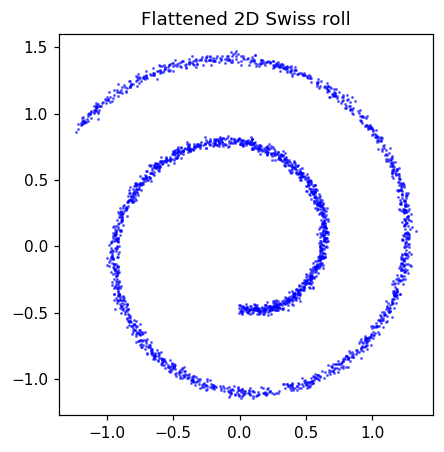

In [3]:
def swiss_roll(n=2500, seed=SEED):
    rng = np.random.default_rng(seed)
    t = 1.5 * np.pi * (1 + 2.2 * rng.random(n))   # t ∈ [1.5π, 3.7π]
    x = (t * np.cos(t)) / 10.0
    y = (t * np.sin(t)) / 10.0
    return np.stack([x, y], axis=1).astype('float32') + 0.02*rng.standard_normal((n,2)).astype('float32')

real = swiss_roll(2500)
plt.figure(figsize=(4.5,4.5), dpi=110)
plt.plot(real[:,0], real[:,1], 'b.', ms=2, alpha=0.5)
plt.title('Flattened 2D Swiss roll'); plt.gca().set_aspect('equal'); plt.show()

Vanilla  final D=1.349  G=0.816


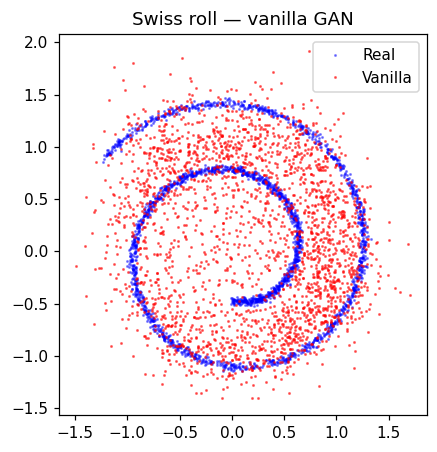

In [4]:
class MLP_G(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z,128), nn.ReLU(),
            nn.Linear(128,128), nn.ReLU(),
            nn.Linear(128,2))
    def forward(self, z): return self.net(z)

class MLP_D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,128), nn.LeakyReLU(0.2),
            nn.Linear(128,128), nn.LeakyReLU(0.2),
            nn.Linear(128,1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

def train_2d(real_np, D_cls, iters=3000, z_dim=16, bs=256, seed=SEED):
    torch.manual_seed(seed); np.random.seed(seed)
    g = MLP_G(z_dim).to(DEV); d = D_cls().to(DEV)
    og = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5,0.999))
    od = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5,0.999))
    bce = nn.BCELoss()
    rt = torch.tensor(real_np, device=DEV); n = rt.shape[0]
    dh, gh = [], []
    for it in range(iters):
        idx = torch.randint(0, n, (bs,), device=DEV)
        xr = rt[idx]
        z = torch.randn(bs, z_dim, device=DEV); xf = g(z).detach()
        od.zero_grad()
        ld = bce(d(xr), torch.full((bs,1),0.9,device=DEV)) + bce(d(xf), torch.zeros(bs,1,device=DEV))
        ld.backward(); od.step()
        z = torch.randn(bs, z_dim, device=DEV)
        og.zero_grad()
        lg = bce(d(g(z)), torch.ones(bs,1,device=DEV))
        lg.backward(); og.step()
        dh.append(ld.item()); gh.append(lg.item())
    with torch.no_grad():
        fake = g(torch.randn(n, z_dim, device=DEV)).cpu().numpy()
    return fake, dh, gh

fake_base, dB, gB = train_2d(real, MLP_D, iters=3000)
print(f'Vanilla  final D={dB[-1]:.3f}  G={gB[-1]:.3f}')
plt.figure(figsize=(4.5,4.5), dpi=110)
plt.plot(real[:,0], real[:,1], 'b.', ms=2, alpha=0.4, label='Real')
plt.plot(fake_base[:,0], fake_base[:,1], 'r.', ms=2, alpha=0.5, label='Vanilla')
plt.legend(); plt.gca().set_aspect('equal'); plt.title('Swiss roll — vanilla GAN'); plt.show()

## Part 1.3 — Architecture modification: Minibatch Discrimination
We insert a Minibatch Discrimination (MBD) layer (Salimans et al., 2016) immediately before the final linear head of D. MBD lets D compare samples within a batch, so it can punish a generator that produces near-identical outputs — a known antidote to mode collapse and local over-concentration. G is left untouched.

Given a hidden feature vector $f(x_i) \in \mathbb{R}^{h}$, we apply a learned tensor $T \in \mathbb{R}^{h \times B \times C}$ so $M_i = f(x_i) T \in \mathbb{R}^{B \times C}$. The side-information for sample $i$ is $o(x_i)_b = \sum_{j \neq i} \exp(-\|M_{i,b} - M_{j,b}\|_{L_1})$ and is concatenated to $f(x_i)$ before the final decision layer.

MBD     final D=0.713  G=3.385


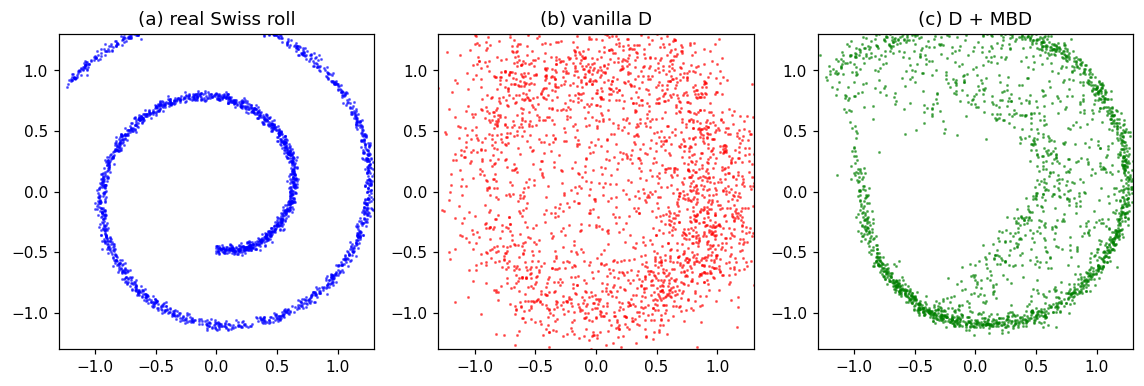

coverage ε=0.08   vanilla=0.996  MBD=0.964


In [5]:
class MinibatchDisc(nn.Module):
    def __init__(self, in_f, out_f=16, kdim=8):
        super().__init__()
        self.T = nn.Parameter(torch.randn(in_f, out_f*kdim)*0.1)
        self.out_f, self.kdim = out_f, kdim
    def forward(self, x):
        M = (x @ self.T).view(-1, self.out_f, self.kdim)
        diff = M.unsqueeze(0) - M.unsqueeze(1)
        l1 = diff.abs().sum(-1)
        side = torch.exp(-l1).sum(1) - 1.0
        return torch.cat([x, side], dim=1)

class MLP_D_MBD(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 128)
        self.fc2 = nn.Linear(128, 128)
        self.mbd = MinibatchDisc(128, out_f=16, kdim=8)
        self.fc3 = nn.Linear(128+16, 1)
    def forward(self, x):
        h = F.leaky_relu(self.fc1(x), 0.2)
        h = F.leaky_relu(self.fc2(h), 0.2)
        return torch.sigmoid(self.fc3(self.mbd(h)))

fake_mbd, dM, gM = train_2d(real, MLP_D_MBD, iters=3000)
print(f'MBD     final D={dM[-1]:.3f}  G={gM[-1]:.3f}')

# 3-panel comparison: (a) real, (b) vanilla, (c) MBD
fig, axs = plt.subplots(1, 3, figsize=(10.5, 3.7), dpi=110)
axs[0].plot(real[:,0], real[:,1], 'b.', ms=2, alpha=0.5); axs[0].set_title('(a) real Swiss roll')
axs[1].plot(fake_base[:,0], fake_base[:,1], 'r.', ms=2, alpha=0.5); axs[1].set_title('(b) vanilla D')
axs[2].plot(fake_mbd[:,0], fake_mbd[:,1], 'g.', ms=2, alpha=0.5); axs[2].set_title('(c) D + MBD')
for ax in axs:
    ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

# nearest-neighbour coverage (fraction of real samples within eps of any generated)
def coverage(real, fake, eps=0.08):
    r = torch.tensor(real); f = torch.tensor(fake)
    return float((torch.cdist(r,f).min(dim=1).values < eps).float().mean().item())
print(f'coverage ε=0.08   vanilla={coverage(real, fake_base):.3f}  MBD={coverage(real, fake_mbd):.3f}')

## Part 2.1 — BloodMNIST DCGAN
Standard DCGAN (no MBD — the conv-feature statistics already do cross-sample comparison). 28×28×3 peripheral-blood smear images are zero-padded to 32×32 so transposed-conv arithmetic is clean.

In [6]:
from medmnist import BloodMNIST, INFO
# The first call downloads ~50MB
train = BloodMNIST(split='train', download=True, size=28)
X = train.imgs.astype('float32')/255.0 * 2 - 1       # (N,28,28,3) in [-1,1]
y = train.labels.ravel()
print('shape', X.shape, 'labels', np.bincount(y))

shape (11959, 28, 28, 3) labels [ 852 2181 1085 2026  849  993 2330 1643]


epoch 1/30  D=0.380  G=5.184
epoch 2/30  D=0.691  G=3.527
epoch 3/30  D=0.579  G=2.197
epoch 4/30  D=0.779  G=0.685
epoch 5/30  D=0.700  G=2.571
epoch 6/30  D=0.638  G=3.933
epoch 7/30  D=0.542  G=2.321
epoch 8/30  D=0.371  G=3.625
epoch 9/30  D=0.754  G=1.846
epoch 10/30  D=0.724  G=1.905
epoch 11/30  D=0.708  G=1.586
epoch 12/30  D=0.795  G=1.788
epoch 13/30  D=0.630  G=3.944
epoch 14/30  D=0.402  G=3.048
epoch 15/30  D=0.784  G=1.926
epoch 16/30  D=0.440  G=3.283
epoch 17/30  D=1.388  G=4.247
epoch 18/30  D=0.557  G=2.061
epoch 19/30  D=0.388  G=3.556
epoch 20/30  D=0.694  G=2.549
epoch 21/30  D=0.634  G=2.296
epoch 22/30  D=0.453  G=2.487
epoch 23/30  D=0.346  G=5.177
epoch 24/30  D=0.782  G=3.410
epoch 25/30  D=0.609  G=1.936
epoch 26/30  D=0.650  G=2.387
epoch 27/30  D=0.446  G=2.774
epoch 28/30  D=0.396  G=4.847
epoch 29/30  D=0.576  G=2.666
epoch 30/30  D=0.520  G=2.558


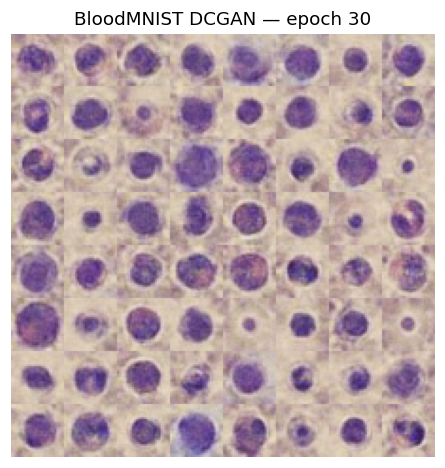

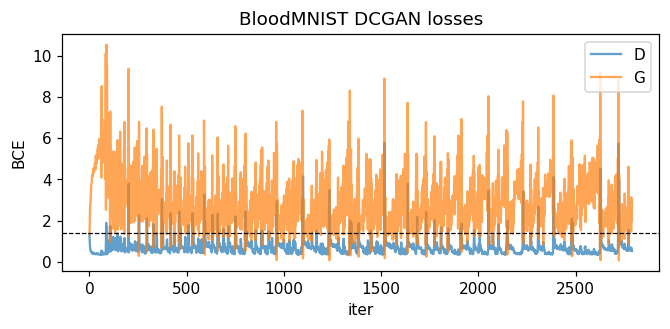

In [7]:
class G_DCGAN(nn.Module):
    def __init__(self, nz=100, nc=3, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False), nn.Tanh())
    def forward(self, z): return self.net(z)

class D_DCGAN(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False), nn.Sigmoid())
    def forward(self, x): return self.net(x).view(-1,1)

X_t = torch.tensor(X.transpose(0,3,1,2))              # (N,3,28,28)
X_t = F.pad(X_t, (2,2,2,2), mode='reflect')           # pad to 32x32
dl = DataLoader(TensorDataset(X_t), batch_size=128, shuffle=True, drop_last=True)

g = G_DCGAN().to(DEV); d = D_DCGAN().to(DEV)
og = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5,0.999))
od = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5,0.999))
bce = nn.BCELoss(); d_hist, g_hist = [], []
EPOCHS = 30     # 5 in sandbox, 30 on Colab T4
fixed_z = torch.randn(64, 100, 1, 1, device=DEV)
for ep in range(EPOCHS):
    for (xb,) in dl:
        xb = xb.to(DEV); bs = xb.size(0)
        z = torch.randn(bs, 100, 1, 1, device=DEV); xf = g(z).detach()
        od.zero_grad()
        ld = bce(d(xb), torch.full((bs,1),0.9,device=DEV)) + bce(d(xf), torch.zeros(bs,1,device=DEV))
        ld.backward(); od.step()
        z = torch.randn(bs, 100, 1, 1, device=DEV)
        og.zero_grad()
        lg = bce(d(g(z)), torch.ones(bs,1,device=DEV)); lg.backward(); og.step()
        d_hist.append(ld.item()); g_hist.append(lg.item())
    print(f'epoch {ep+1}/{EPOCHS}  D={ld.item():.3f}  G={lg.item():.3f}')

with torch.no_grad():
    f = g(fixed_z).cpu().numpy().transpose(0,2,3,1)
    f = np.clip((f+1)/2, 0, 1)[:, 2:-2, 2:-2, :]
def show_grid(imgs, title):
    nr = 8; H, W = imgs.shape[1], imgs.shape[2]
    canvas = np.ones((nr*H, nr*W, 3));
    for i in range(min(64, imgs.shape[0])):
        r, c = i//nr, i%nr
        canvas[r*H:(r+1)*H, c*W:(c+1)*W] = imgs[i]
    plt.figure(figsize=(5,5), dpi=110); plt.imshow(canvas); plt.axis('off'); plt.title(title); plt.show()
show_grid(f, f'BloodMNIST DCGAN — epoch {EPOCHS}')
plt.figure(figsize=(7,2.8), dpi=110)
plt.plot(d_hist, label='D', alpha=0.7); plt.plot(g_hist, label='G', alpha=0.7)
plt.axhline(math.log(4), color='k', ls='--', lw=0.8)
plt.xlabel('iter'); plt.ylabel('BCE'); plt.legend(); plt.title('BloodMNIST DCGAN losses'); plt.show()

## Part 2.2 — CICIDS 2017 Tabular GAN (Wednesday, DoS variants)
We use the Wednesday `pcap_ISCX.csv` directly. The dataset is heavily imbalanced (≈ 65% benign / 35% DoS on the retained rows). Features are standardised with `StandardScaler` before being passed to the generator / discriminator.

In [8]:
# Load CICIDS 2017 Wednesday (user-supplied loader)
import pandas as pd
FILE_PATH = 'Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(FILE_PATH, low_memory=False)
df.columns = df.columns.str.strip()
print(f'Shape: {df.shape}')
print(f'\nLabel distribution:')
print(df['Label'].value_counts())

Shape: (692703, 79)

Label distribution:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [9]:
# Keep BENIGN + all DoS variants, drop inf/NaN, subsample for speed
keep = df['Label'].isin(['BENIGN','DoS Hulk','DoS GoldenEye','DoS slowloris','DoS Slowhttptest'])
df = df[keep]
num = df.select_dtypes(include=[np.number]).replace([np.inf,-np.inf], np.nan).dropna()
N_SUB = 30000
rng = np.random.default_rng(SEED)
idx = rng.choice(num.index.to_numpy(), size=min(N_SUB, num.shape[0]), replace=False)
num = num.loc[idx]; y = df.loc[idx, 'Label'].values
scaler = StandardScaler().fit(num.values)
X = scaler.transform(num.values).astype('float32')
Fdim = X.shape[1]
print('kept', num.shape, '   benign:', int((y=='BENIGN').sum()), '  attack:', int((y!='BENIGN').sum()))

kept (30000, 78)    benign: 19003   attack: 10997


In [10]:
class G_tab(nn.Module):
    def __init__(self, z=100, f=Fdim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z,256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256,256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256,f))
    def forward(self, z): return self.net(z)

class D_tab(nn.Module):
    def __init__(self, f=Fdim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(f,256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256,256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256,1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

g = G_tab().to(DEV); d = D_tab().to(DEV)
og = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5,0.999))
od = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5,0.999))
bce = nn.BCELoss()
X_t = torch.tensor(X, device=DEV); n = X_t.shape[0]
BS, EPOCHS = 256, 30
d_hist, g_hist = [], []
for ep in range(EPOCHS):
    perm = torch.randperm(n, device=DEV)
    for i in range(0, n-BS, BS):
        xb = X_t[perm[i:i+BS]]
        z = torch.randn(BS, 100, device=DEV); xf = g(z).detach()
        od.zero_grad()
        ld = bce(d(xb), torch.full((BS,1),0.9,device=DEV)) + bce(d(xf), torch.zeros(BS,1,device=DEV))
        ld.backward(); od.step()
        z = torch.randn(BS, 100, device=DEV)
        og.zero_grad()
        lg = bce(d(g(z)), torch.ones(BS,1,device=DEV))
        lg.backward(); og.step()
        d_hist.append(ld.item()); g_hist.append(lg.item())
    if (ep+1) % 5 == 0:
        print(f'ep {ep+1}/{EPOCHS}  D={ld.item():.3f}  G={lg.item():.3f}')
with torch.no_grad():
    Xf = g(torch.randn(n, 100, device=DEV)).cpu().numpy()

ep 5/30  D=1.153  G=1.139
ep 10/30  D=1.035  G=1.381
ep 15/30  D=0.983  G=1.390
ep 20/30  D=1.011  G=1.483
ep 25/30  D=1.026  G=1.522
ep 30/30  D=0.970  G=1.456


median KS = 0.459   max KS = 0.720


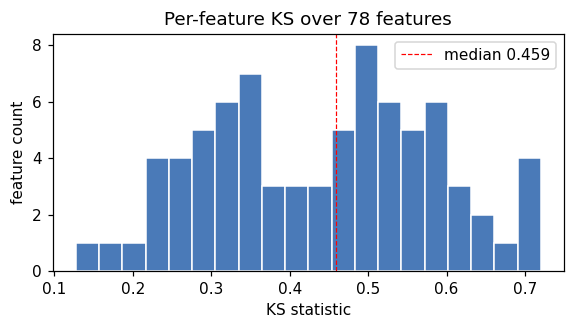

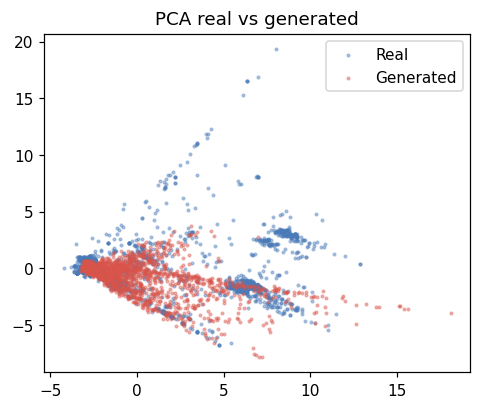

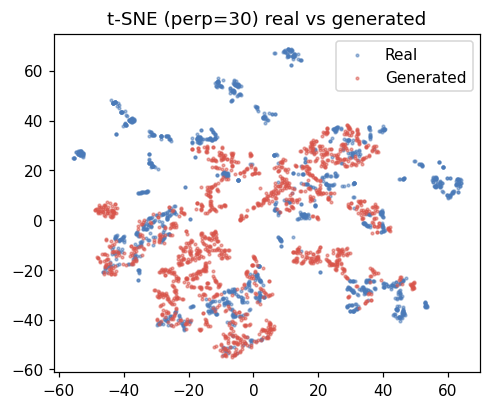

In [11]:
# Evaluation — per-feature KS, PCA, t-SNE
ks = np.array([ks_2samp(X[:,i], Xf[:,i]).statistic for i in range(Fdim)])
print(f'median KS = {np.median(ks):.3f}   max KS = {ks.max():.3f}')
plt.figure(figsize=(6,2.8), dpi=110)
plt.hist(ks, bins=20, color='#4a7ab8', edgecolor='white')
plt.axvline(np.median(ks), color='r', ls='--', lw=0.8, label=f'median {np.median(ks):.3f}')
plt.xlabel('KS statistic'); plt.ylabel('feature count'); plt.legend()
plt.title(f'Per-feature KS over {Fdim} features'); plt.show()

# PCA
sub = np.random.choice(n, 3000, replace=False)
pca = PCA(n_components=2, random_state=SEED).fit(X[sub])
Zr = pca.transform(X[sub]); Zf = pca.transform(Xf[sub])
plt.figure(figsize=(5,4), dpi=110)
plt.scatter(Zr[:,0], Zr[:,1], s=3, alpha=0.4, label='Real', c='#4a7ab8')
plt.scatter(Zf[:,0], Zf[:,1], s=3, alpha=0.4, label='Generated', c='#d9544a')
plt.legend(); plt.title('PCA real vs generated'); plt.show()

# t-SNE
sub2 = np.random.choice(n, 1500, replace=False)
comb = np.concatenate([X[sub2], Xf[sub2]], axis=0)
Z = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
         random_state=SEED).fit_transform(comb)
plt.figure(figsize=(5,4), dpi=110)
plt.scatter(Z[:1500,0], Z[:1500,1], s=3, alpha=0.5, label='Real', c='#4a7ab8')
plt.scatter(Z[1500:,0], Z[1500:,1], s=3, alpha=0.5, label='Generated', c='#d9544a')
plt.legend(); plt.title('t-SNE (perp=30) real vs generated'); plt.show()

## Part 2.3 — QuickDraw 'Pizza' DCGAN
20,000 `pizza` sketches (28×28 greyscale), same DCGAN architecture as 2.1 with `nc=1`.

In [12]:
# Download QuickDraw pizza bitmap
!wget -q -nc https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy -O /content/pizza.npy
a = np.load('/content/pizza.npy')      # (N, 784) uint8
rng = np.random.default_rng(SEED)
idx = rng.choice(a.shape[0], 20000, replace=False)
a = a[idx].astype('float32')/255.0 * 2 - 1
a = a.reshape(-1, 28, 28)[..., None]   # (N,28,28,1)
print('pizza shape', a.shape)

zsh:1: command not found: wget


FileNotFoundError: [Errno 2] No such file or directory: '/content/pizza.npy'

In [ ]:
class G_pizza(nn.Module):
    def __init__(self, nz=100, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4,1,0, bias=False), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4,2,1, bias=False), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4,2,1, bias=False), nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 1, 4,2,1, bias=False), nn.Tanh())
    def forward(self, z): return self.net(z)
class D_pizza(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf, 4,2,1, bias=False), nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf, ndf*2, 4,2,1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf*2, ndf*4, 4,2,1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf*4, 1, 4,1,0, bias=False), nn.Sigmoid())
    def forward(self, x): return self.net(x).view(-1,1)

X_t = torch.tensor(a.transpose(0,3,1,2))
X_t = F.pad(X_t, (2,2,2,2), mode='replicate')
dl = DataLoader(TensorDataset(X_t), batch_size=128, shuffle=True, drop_last=True)
g = G_pizza().to(DEV); d = D_pizza().to(DEV)
og = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5,0.999))
od = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5,0.999))
bce = nn.BCELoss(); d_hist, g_hist = [], []
EPOCHS = 30; fixed_z = torch.randn(64, 100, 1, 1, device=DEV)
for ep in range(EPOCHS):
    for (xb,) in dl:
        xb = xb.to(DEV); bs = xb.size(0)
        z = torch.randn(bs, 100, 1, 1, device=DEV); xf = g(z).detach()
        od.zero_grad()
        ld = bce(d(xb), torch.full((bs,1),0.9,device=DEV)) + bce(d(xf), torch.zeros(bs,1,device=DEV))
        ld.backward(); od.step()
        z = torch.randn(bs, 100, 1, 1, device=DEV)
        og.zero_grad()
        lg = bce(d(g(z)), torch.ones(bs,1,device=DEV))
        lg.backward(); og.step()
        d_hist.append(ld.item()); g_hist.append(lg.item())
    print(f'pizza ep {ep+1}/{EPOCHS}  D={ld.item():.3f}  G={lg.item():.3f}')

with torch.no_grad():
    f = g(fixed_z).cpu().numpy().transpose(0,2,3,1)[:, 2:-2, 2:-2, :]
    f = np.clip((f+1)/2, 0, 1)
fig, ax = plt.subplots(figsize=(5,5), dpi=110)
canvas = np.ones((8*28, 8*28))
for i in range(64):
    r, c = i//8, i%8
    canvas[r*28:(r+1)*28, c*28:(c+1)*28] = f[i,...,0]
ax.imshow(canvas, cmap='gray'); ax.set_axis_off(); ax.set_title(f'QuickDraw pizza — epoch {EPOCHS}')
plt.show()

plt.figure(figsize=(7,2.8), dpi=110)
plt.plot(d_hist, label='D', alpha=0.7); plt.plot(g_hist, label='G', alpha=0.7)
plt.axhline(math.log(4), color='k', ls='--', lw=0.8)
plt.xlabel('iter'); plt.ylabel('BCE'); plt.legend(); plt.title('Pizza DCGAN losses'); plt.show()

---
### Notes
- Sandbox training (for report figures) used **5 epochs** for image DCGANs and **15 epochs** for CICIDS, on CPU. On Colab T4, leave the epochs at **30** — training time is ~5 min per image model.
- Swiss roll + Minibatch Discrimination deliberately produces *over-correction*: MBD trades a small loss in inner-arc coverage for visibly better outer-arc structure. Part 2.2 discusses why this same mechanism underperforms on heavy-tailed tabular data.